<a href="https://colab.research.google.com/github/EbyJK/btech-honors-project/blob/main/Deeplab_road.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("balraj98/deepglobe-road-extraction-dataset")

print("Path to dataset files:", path)

100%|██████████| 3.79G/3.79G [00:20<00:00, 199MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/balraj98/deepglobe-road-extraction-dataset/versions/2


In [ ]:
import os, cv2
import numpy as np
import pandas as pd
import random, tqdm
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import albumentations as album
!pip install -q -U segmentation-models-pytorch albumentations
!pip install -q torchmetrics
import segmentation_models_pytorch as smp
import torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.2 MB/s eta 0:00:00


In [ ]:
DATA_DIR = '/root/.cache/kagglehub/datasets/balraj98/deepglobe-road-extraction-dataset/versions/2'

metadata_df = pd.read_csv(os.path.join(DATA_DIR, 'metadata.csv'))
metadata_df = metadata_df[metadata_df['split']=='train']
metadata_df = metadata_df[['image_id', 'sat_image_path', 'mask_path']]
metadata_df['sat_image_path'] = metadata_df['sat_image_path'].apply(lambda img_pth: os.path.join(DATA_DIR, img_pth))
metadata_df['mask_path'] = metadata_df['mask_path'].apply(lambda img_pth: os.path.join(DATA_DIR, img_pth))
# Shuffle DataFrame
metadata_df = metadata_df.sample(frac=1).reset_index(drop=True)

# Perform 90/10 split for train / val
valid_df = metadata_df.sample(frac=0.1, random_state=42)
train_df = metadata_df.drop(valid_df.index)
len(train_df), len(valid_df)

class_dict = pd.read_csv(os.path.join(DATA_DIR, 'class_dict.csv'))
# Get class names
class_names = class_dict['name'].tolist()
# Get class RGB values
class_rgb_values = class_dict[['r','g','b']].values.tolist()

print('All dataset classes and their corresponding RGB values in labels:')
print('Class Names: ', class_names)
print('Class RGB values: ', class_rgb_values)

All dataset classes and their corresponding RGB values in labels:
Class Names:  ['road', 'background']
Class RGB values:  [[255, 255, 255], [0, 0, 0]]


In [ ]:
# Useful to shortlist specific classes in datasets with large number of classes
select_classes = ['background', 'road']

# Get RGB values of required classes
select_class_indices = [class_names.index(cls.lower()) for cls in select_classes]
select_class_rgb_values =  np.array(class_rgb_values)[select_class_indices]

print('Selected classes and their corresponding RGB values in labels:')
print('Class Names: ', class_names)
print('Class RGB values: ', class_rgb_values)

Selected classes and their corresponding RGB values in labels:
Class Names:  ['road', 'background']
Class RGB values:  [[255, 255, 255], [0, 0, 0]]


In [ ]:
# helper function for data visualization
def visualize(**images):
    """
    Plot images in one row
    """
    n_images = len(images)
    plt.figure(figsize=(20,8))
    for idx, (name, image) in enumerate(images.items()):
        plt.subplot(1, n_images, idx + 1)
        plt.xticks([]);
        plt.yticks([])
        # get title from the parameter names
        plt.title(name.replace('_',' ').title(), fontsize=20)
        plt.imshow(image)
    plt.show()

# Perform one hot encoding on label
def one_hot_encode(label, label_values):
    """
    Convert a segmentation image label array to one-hot format
    by replacing each pixel value with a vector of length num_classes
    # Arguments
        label: The 2D array segmentation image label
        label_values

    # Returns
        A 2D array with the same width and hieght as the input, but
        with a depth size of num_classes
    """
    semantic_map = []
    for colour in label_values:
        equality = np.equal(label, colour)
        class_map = np.all(equality, axis = -1)
        semantic_map.append(class_map)
    semantic_map = np.stack(semantic_map, axis=-1)

    return semantic_map

# Perform reverse one-hot-encoding on labels / preds
def reverse_one_hot(image):
    """
    Transform a 2D array in one-hot format (depth is num_classes),
    to a 2D array with only 1 channel, where each pixel value is
    the classified class key.
    # Arguments
        image: The one-hot format image

    # Returns
        A 2D array with the same width and hieght as the input, but
        with a depth size of 1, where each pixel value is the classified
        class key.
    """
    x = np.argmax(image, axis = -1)
    return x

# Perform colour coding on the reverse-one-hot outputs
def colour_code_segmentation(image, label_values):
    """
    Given a 1-channel array of class keys, colour code the segmentation results.
    # Arguments
        image: single channel array where each value represents the class key.
        label_values

    # Returns
        Colour coded image for segmentation visualization
    """
    colour_codes = np.array(label_values)
    x = colour_codes[image.astype(int)]

    return x

In [ ]:
class RoadsDataset(torch.utils.data.Dataset):

    """DeepGlobe Road Extraction Challenge Dataset. Read images, apply augmentation and preprocessing transformations.

    Args:
        df (str): DataFrame containing images / labels paths
        class_rgb_values (list): RGB values of select classes to extract from segmentation mask
        augmentation (albumentations.Compose): data transfromation pipeline
            (e.g. flip, scale, etc.)
        preprocessing (albumentations.Compose): data preprocessing
            (e.g. noralization, shape manipulation, etc.)

    """
    def __init__(
            self,
            df,
            class_rgb_values=None,
            augmentation=None,
            preprocessing=None,
    ):
        self.image_paths = df['sat_image_path'].tolist()
        self.mask_paths = df['mask_path'].tolist()

        self.class_rgb_values = class_rgb_values
        self.augmentation = augmentation
        self.preprocessing = preprocessing

    def __getitem__(self, i):

        # read images and masks
        image = cv2.cvtColor(cv2.imread(self.image_paths[i]), cv2.COLOR_BGR2RGB)
        mask = cv2.cvtColor(cv2.imread(self.mask_paths[i]), cv2.COLOR_BGR2RGB)

        # one-hot-encode the mask
        mask = one_hot_encode(mask, self.class_rgb_values).astype('float')

        # apply augmentations
        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']

        # apply preprocessing
        if self.preprocessing:
            sample = self.preprocessing(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']

        return image, mask

    def __len__(self):
        # return length of
        return len(self.image_paths)

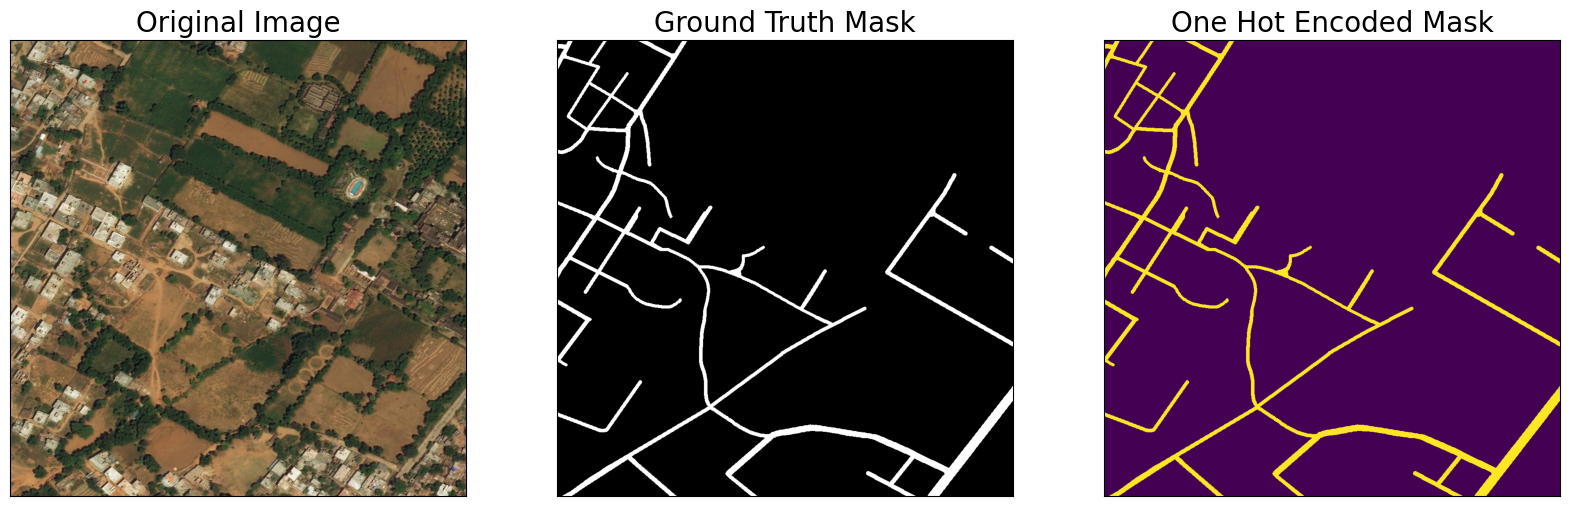

In [ ]:
dataset = RoadsDataset(train_df, class_rgb_values=select_class_rgb_values)
random_idx = random.randint(0, len(dataset)-1)
image, mask = dataset[2]

visualize(
    original_image = image,
    ground_truth_mask = colour_code_segmentation(reverse_one_hot(mask), select_class_rgb_values),
    one_hot_encoded_mask = reverse_one_hot(mask)
)

In [ ]:
def get_training_augmentation():
    train_transform = [
        album.HorizontalFlip(p=0.5),
        album.VerticalFlip(p=0.5),
    ]
    return album.Compose(train_transform)


def to_tensor(x, **kwargs):
    return x.transpose(2, 0, 1).astype('float32')


def get_preprocessing(preprocessing_fn=None):
    """Construct preprocessing transform
    Args:
        preprocessing_fn (callable): data normalization function
            (can be specific for each pretrained neural network)
    Return:
        transform: albumentations.Compose
    """
    _transform = []
    if preprocessing_fn:
        _transform.append(album.Lambda(image=preprocessing_fn))
    _transform.append(album.Lambda(image=to_tensor, mask=to_tensor))

    return album.Compose(_transform)

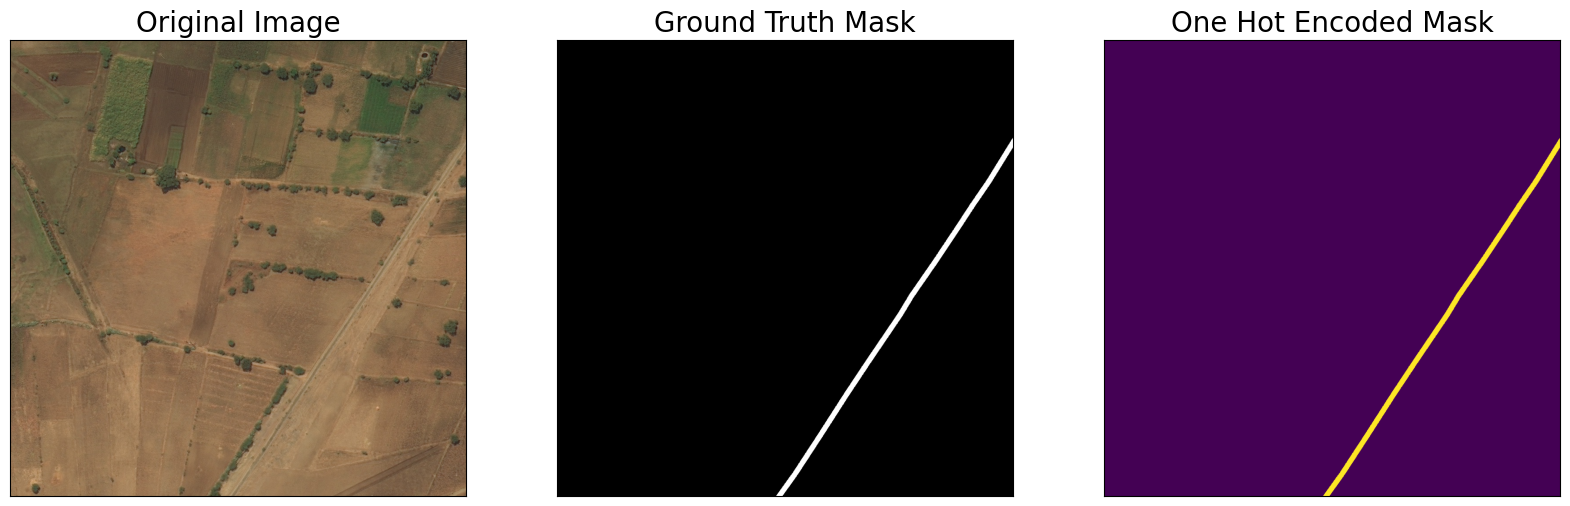

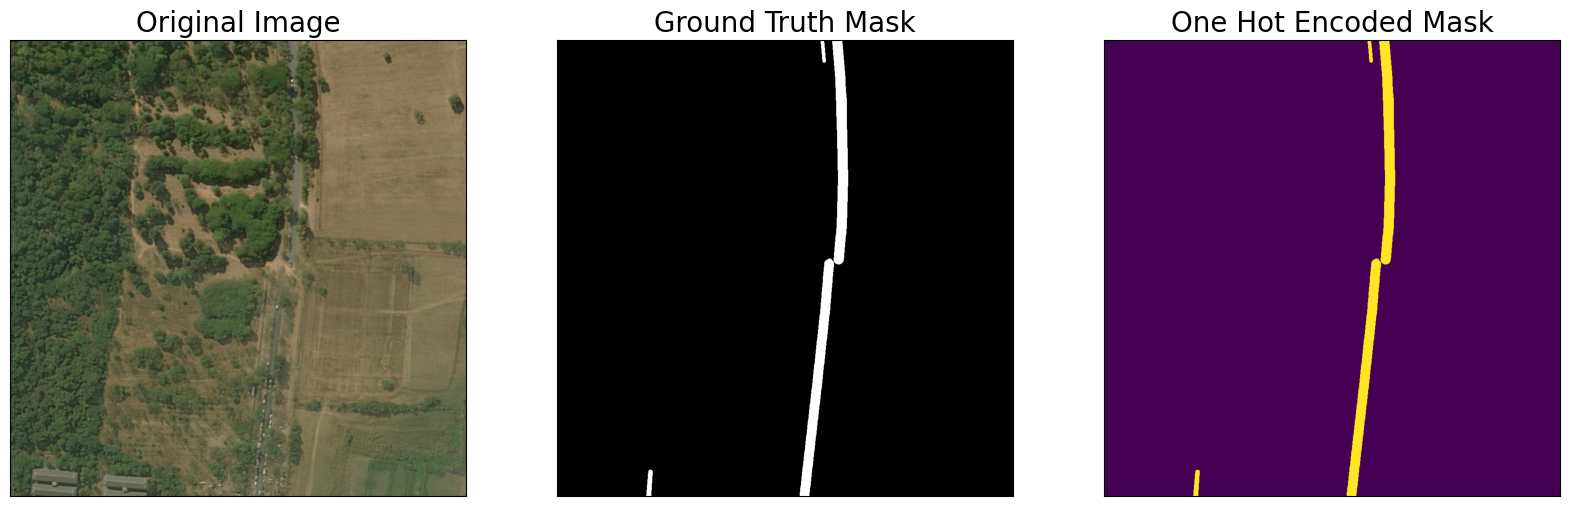

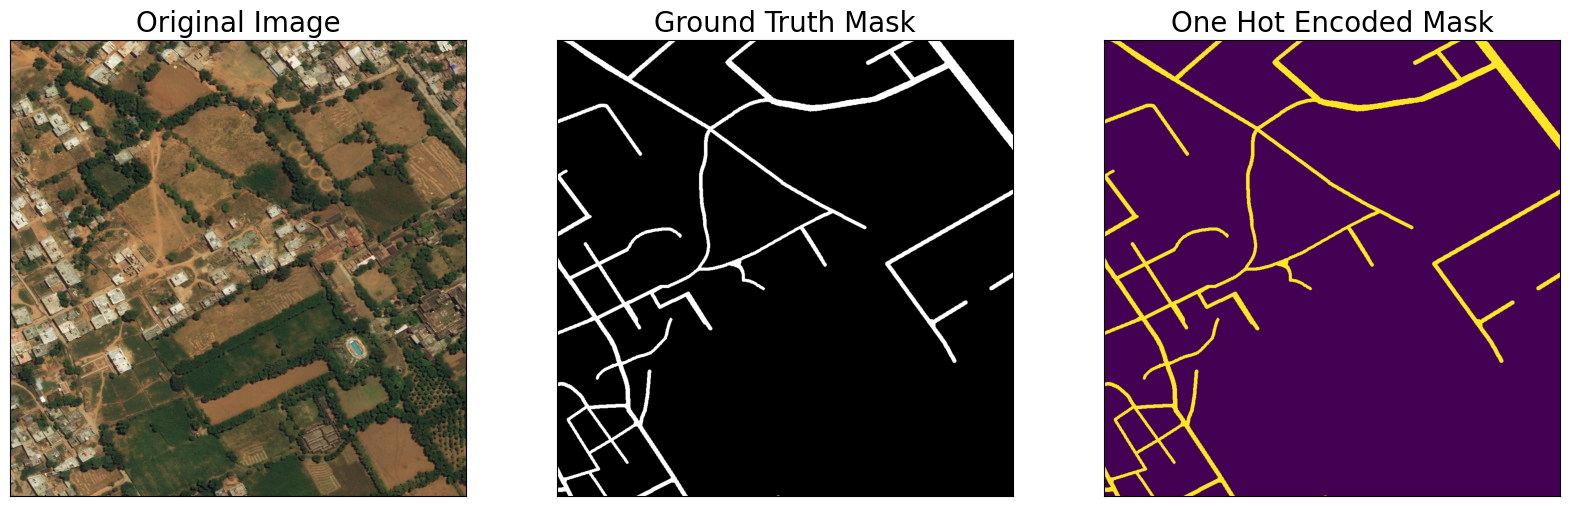

In [ ]:
augmented_dataset = RoadsDataset(
    train_df,
    augmentation=get_training_augmentation(),
    class_rgb_values=select_class_rgb_values,
)

random_idx = random.randint(0, len(augmented_dataset)-1)

# Different augmentations on image/mask pairs
for idx in range(3):
    image, mask = augmented_dataset[idx]
    visualize(
        original_image = image,
        ground_truth_mask = colour_code_segmentation(reverse_one_hot(mask), select_class_rgb_values),
        one_hot_encoded_mask = reverse_one_hot(mask)
    )

In [ ]:
ENCODER = 'resnet50'
ENCODER_WEIGHTS = 'imagenet'
CLASSES = select_classes
ACTIVATION = 'sigmoid' # could be None for logits or 'softmax2d' for multiclass segmentation

# create segmentation model with pretrained encoder
model = smp.DeepLabV3Plus(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    classes=len(CLASSES),
    activation=ACTIVATION,
)

preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER, ENCODER_WEIGHTS)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [ ]:
train_dataset = RoadsDataset(
    train_df,
    augmentation=get_training_augmentation(),
    preprocessing=get_preprocessing(preprocessing_fn),
    class_rgb_values=select_class_rgb_values,
)

valid_dataset = RoadsDataset(
    valid_df,
    preprocessing=get_preprocessing(preprocessing_fn),
    class_rgb_values=select_class_rgb_values,
)

# Get train and val data loaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=1)
valid_loader = DataLoader(valid_dataset, batch_size=4, shuffle=False, num_workers=1)

In [ ]:
TRAINING = True

# Set num of epochs
EPOCHS = 3

# Set device: `cuda` or `cpu`
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# define loss function
loss = smp.losses.DiceLoss(mode='binary')

# define metrics
metrics = [
    torchmetrics.JaccardIndex(task='binary', num_classes=len(CLASSES), threshold=0.5).to(DEVICE),
]

# define optimizer
optimizer = torch.optim.Adam([
    dict(params=model.parameters(), lr=0.00008),
])

# define learning rate scheduler (not used in this NB)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=1, T_mult=2, eta_min=5e-5,
)

# load best saved model checkpoint from previous commit (if present)
if os.path.exists('/content/best_road_model.pth'):
    model = torch.load('/content/best_road_model.pth', map_location=DEVICE)
    print('Loaded pre-trained DeepLabV3+ model!')

In [ ]:
class Trainer:
    def __init__(
        self, model, device, loss, optimizer, lr_scheduler, train_dataloader, valid_dataloader, metrics
    ):
        self.model = model
        self.device = device
        self.loss = loss
        self.optimizer = optimizer
        self.lr_scheduler = lr_scheduler
        self.train_dataloader = train_dataloader
        self.valid_dataloader = valid_dataloader
        self.metrics = metrics

        self.model.to(self.device)

    def _train_epoch(self, epoch):
        self.model.train()
        running_loss = 0.0
        for i, (images, masks) in enumerate(self.train_dataloader):
            images = images.to(self.device)
            masks = masks.to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss_value = self.loss(outputs, masks)
            loss_value.backward()
            self.optimizer.step()
            self.lr_scheduler.step(epoch + i / len(self.train_dataloader))

            running_loss += loss_value.item()

        return running_loss / len(self.train_dataloader)

    def _validate_epoch(self):
        self.model.eval()
        total_loss = 0.0
        total_metrics = {m.__class__.__name__: 0.0 for m in self.metrics}

        with torch.no_grad():
            for images, masks in self.valid_dataloader:
                images = images.to(self.device)
                masks = masks.to(self.device)

                outputs = self.model(images)
                loss_value = self.loss(outputs, masks)
                total_loss += loss_value.item()

                for metric in self.metrics:
                    metric_value = metric(outputs.float(), masks.long())
                    total_metrics[metric.__class__.__name__] += metric_value.item()

        avg_loss = total_loss / len(self.valid_dataloader)
        avg_metrics = {k: v / len(self.valid_dataloader) for k, v in total_metrics.items()}
        return avg_loss, avg_metrics

    def train(self, num_epochs):
        best_loss = float('inf')
        for epoch in range(num_epochs):
            train_loss = self._train_epoch(epoch)
            val_loss, val_metrics = self._validate_epoch()

            print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
            for metric_name, metric_value in val_metrics.items():
                print(f"  {metric_name}: {metric_value:.4f}")

            if val_loss < best_loss:
                best_loss = val_loss
                torch.save(self.model, './best_road_model.pth')
                print("Model saved!")

trainer = Trainer(
    model,
    DEVICE,
    loss,
    optimizer,
    lr_scheduler,
    train_loader,
    valid_loader,
    metrics
)

if TRAINING:
    trainer.train(EPOCHS)


Epoch 1/3: Train Loss: 0.3623, Val Loss: 0.3532
  BinaryJaccardIndex: 0.9329
Model saved!
Epoch 2/3: Train Loss: 0.3508, Val Loss: 0.3500
  BinaryJaccardIndex: 0.9478
Model saved!
Epoch 3/3: Train Loss: 0.3495, Val Loss: 0.3492
  BinaryJaccardIndex: 0.9541
Model saved!


In [ ]:
import os
import cv2
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Recommended to install in Colab:
!pip install segmentation-models-pytorch albumentations -q
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ==========================================
# 1. CONFIGURATION & HYPERPARAMETERS
# ==========================================
class Config:
    # --- PATHS ---
    # Directory containing all your train images and masks
    DATASET_DIR = "/root/.cache/kagglehub/datasets/balraj98/deepglobe-road-extraction-dataset/versions/2/train"

    # Suffixes for images and masks based on your dataset structure
    IMAGE_SUFFIX = "_sat"
    MASK_SUFFIX = "_mask"

    # --- SPLITS ---
    VAL_SPLIT = 0.1  # 10% for validation
    TEST_SPLIT = 0.1 # 10% for testing (remaining 80% is train)

    # --- TRAINING PARAMETERS ---
    BATCH_SIZE = 8
    EPOCHS = 50
    LEARNING_RATE = 1e-4
    IMAGE_SIZE = 512

    # --- EARLY STOPPING ---
    PATIENCE = 7
    MIN_DELTA = 0.001

    # --- SYSTEM ---
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    NUM_WORKERS = 2 # 2 is usually optimal for Colab
    MODEL_SAVE_PATH = "/content/best_deeplabv3_model.pth"

# ==========================================
# 2. HELPER FUNCTIONS: DATA MATCHING
# ==========================================
def get_all_matched_paths(data_dir):
    """
    Matches images and masks based on the ID prefix before '_sat' and '_mask'.
    Assumes all files are directly inside a single directory.
    """
    if not os.path.exists(data_dir):
        print(f"Directory missing: {data_dir}")
        return [], []

    # Get all files in the directory
    all_files = sorted(os.listdir(data_dir))

    # Separate into images and masks based on suffix
    image_files = [f for f in all_files if Config.IMAGE_SUFFIX in f]
    mask_files = [f for f in all_files if Config.MASK_SUFFIX in f]

    # Create a dictionary mapping the base ID to the mask filename
    # e.g., '12345' -> '12345_mask.png'
    mask_dict = {f.split(Config.MASK_SUFFIX)[0]: f for f in mask_files}

    image_paths = []
    mask_paths = []

    for img_name in image_files:
        # Extract the ID from the image filename (e.g., '12345_sat.jpg' -> '12345')
        img_id = img_name.split(Config.IMAGE_SUFFIX)[0]

        if img_id in mask_dict:
            image_paths.append(os.path.join(data_dir, img_name))
            mask_paths.append(os.path.join(data_dir, mask_dict[img_id]))
        else:
            print(f"Warning: No matching mask found for {img_name}.")

    print(f"Found {len(image_paths)} total matching image-mask pairs in {data_dir}.")
    return image_paths, mask_paths

# ==========================================
# 3. DATASET & TRANSFORMS
# ==========================================
class RoadDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Read Image (Convert BGR to RGB)
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Read Mask (Grayscale)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = (mask / 255.0).astype(np.float32) # Normalize to 0-1

        if self.transform:
            augmentations = self.transform(image=image, mask=mask)
            image = augmentations["image"]
            mask = augmentations["mask"]

        mask = mask.unsqueeze(0) # (H, W) -> (1, H, W)
        return image, mask

def get_train_transforms():
    return A.Compose([
        A.Resize(Config.IMAGE_SIZE, Config.IMAGE_SIZE),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

def get_val_transforms():
    return A.Compose([
        A.Resize(Config.IMAGE_SIZE, Config.IMAGE_SIZE),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

# ==========================================
# 4. METRICS & EARLY STOPPING
# ==========================================
def calculate_metrics(preds, labels, threshold=0.5):
    """Calculates Intersection over Union (IoU) and Pixel Accuracy."""
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()

    # 1. Intersection over Union (IoU)
    intersection = (preds * labels).sum()
    union = preds.sum() + labels.sum() - intersection
    iou = (intersection / union).item() if union != 0 else 1.0

    # 2. Pixel Accuracy
    correct = (preds == labels).sum()
    total = torch.numel(preds)
    accuracy = (correct / total).item()

    return iou, accuracy

class EarlyStopping:
    def __init__(self, patience=7, min_delta=0, path='best_model.pth'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        print(f'Validation loss decreased. Saving best model...')
        torch.save(model.state_dict(), self.path)

# ==========================================
# 5. TRAINING, VALIDATION & TESTING LOOPS
# ==========================================
def train_one_epoch(loader, model, optimizer, criterion, device):
    model.train()
    running_loss, running_iou, running_acc = 0.0, 0.0, 0.0

    loop = tqdm(loader, desc="Training", leave=False)
    for images, masks in loop:
        images, masks = images.to(device), masks.to(device)

        predictions = model(images)
        loss = criterion(predictions, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        iou, acc = calculate_metrics(predictions, masks)
        running_loss += loss.item()
        running_iou += iou
        running_acc += acc
        loop.set_postfix(loss=loss.item(), iou=iou)

    return running_loss / len(loader), running_iou / len(loader), running_acc / len(loader)

def validate_one_epoch(loader, model, criterion, device):
    model.eval()
    running_loss, running_iou, running_acc = 0.0, 0.0, 0.0

    loop = tqdm(loader, desc="Validation", leave=False)
    with torch.no_grad():
        for images, masks in loop:
            images, masks = images.to(device), masks.to(device)
            predictions = model(images)
            loss = criterion(predictions, masks)

            iou, acc = calculate_metrics(predictions, masks)
            running_loss += loss.item()
            running_iou += iou
            running_acc += acc
            loop.set_postfix(loss=loss.item(), iou=iou)

    return running_loss / len(loader), running_iou / len(loader), running_acc / len(loader)

def test_model(loader, model, device):
    print("\nStarting Evaluation on Test Set...")
    model.eval()
    running_iou, running_acc = 0.0, 0.0

    loop = tqdm(loader, desc="Testing", leave=False)
    with torch.no_grad():
        for images, masks in loop:
            images, masks = images.to(device), masks.to(device)
            predictions = model(images)

            iou, acc = calculate_metrics(predictions, masks)
            running_iou += iou
            running_acc += acc
            loop.set_postfix(iou=iou, acc=acc)

    avg_iou = running_iou / len(loader)
    avg_acc = running_acc / len(loader)

    print("\n" + "="*40)
    print(f"🏆 FINAL TEST SET RESULTS 🏆")
    print("="*40)
    print(f"Test IoU:      {avg_iou:.4f}")
    print(f"Test Accuracy: {avg_acc:.4f}")
    print("="*40)

# ==========================================
# 6. MAIN PIPELINE EXECUTION
# ==========================================
def main():
    print(f"Using device: {Config.DEVICE}")

    # 1. Match all Data Paths from the single train folder
    all_imgs, all_masks = get_all_matched_paths(Config.DATASET_DIR)

    if not all_imgs:
        print("Please fix the dataset path before running.")
        return

    # 1b. Perform custom train/val/test splits
    temp_size = Config.VAL_SPLIT + Config.TEST_SPLIT
    train_imgs, temp_imgs, train_masks, temp_masks = train_test_split(
        all_imgs, all_masks, test_size=temp_size, random_state=42
    )

    # Split the temp set equally into validation and test sets
    val_ratio_in_temp = Config.VAL_SPLIT / temp_size
    valid_imgs, test_imgs, valid_masks, test_masks = train_test_split(
        temp_imgs, temp_masks, test_size=(1.0 - val_ratio_in_temp), random_state=42
    )

    print(f"Split completed! Train: {len(train_imgs)}, Valid: {len(valid_imgs)}, Test: {len(test_imgs)}")

    # 2. Create Datasets and DataLoaders
    train_dataset = RoadDataset(train_imgs, train_masks, transform=get_train_transforms())
    valid_dataset = RoadDataset(valid_imgs, valid_masks, transform=get_val_transforms())
    test_dataset  = RoadDataset(test_imgs,  test_masks,  transform=get_val_transforms())

    train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=Config.NUM_WORKERS)
    valid_loader = DataLoader(valid_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS)
    test_loader  = DataLoader(test_dataset,  batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS)

    # 3. Initialize Model
    model = smp.DeepLabV3Plus(
        encoder_name="resnet50",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
    ).to(Config.DEVICE)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=Config.LEARNING_RATE)

    early_stopping = EarlyStopping(
        patience=Config.PATIENCE,
        min_delta=Config.MIN_DELTA,
        path=Config.MODEL_SAVE_PATH
    )

    # 4. Training & Validation Loop
    print("\nStarting Training...\n" + "-"*40)
    for epoch in range(1, Config.EPOCHS + 1):
        print(f"Epoch {epoch}/{Config.EPOCHS}")

        train_loss, train_iou, train_acc = train_one_epoch(train_loader, model, optimizer, criterion, Config.DEVICE)
        val_loss, val_iou, val_acc = validate_one_epoch(valid_loader, model, criterion, Config.DEVICE)

        print(f"Train Loss: {train_loss:.4f} | Train IoU: {train_iou:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val IoU:   {val_iou:.4f} | Val Acc:   {val_acc:.4f}")
        print("-" * 40)

        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print(f"Early stopping triggered at epoch {epoch}. Training halted.")
            break

    # 5. Testing Loop
    print(f"\nLoading best model weights from {Config.MODEL_SAVE_PATH} for Testing...")
    model.load_state_dict(torch.load(Config.MODEL_SAVE_PATH, map_location=Config.DEVICE))
    test_model(test_loader, model, Config.DEVICE)

if __name__ == "__main__":
    # Ensure Config.DATASET_BASE_DIR correctly points to the root of your train/valid/test folders
    main()

Using device: cuda
Found 6226 total matching image-mask pairs in /root/.cache/kagglehub/datasets/balraj98/deepglobe-road-extraction-dataset/versions/2/train.
Split completed! Train: 4980, Valid: 623, Test: 623

Starting Training...
----------------------------------------
Epoch 1/50


Train Loss: 0.1775 | Train IoU: 0.1186 | Train Acc: 0.9528
Val Loss:   0.1047 | Val IoU:   0.3174 | Val Acc:   0.9652
----------------------------------------
Validation loss decreased. Saving best model...
Epoch 2/50


Train Loss: 0.0888 | Train IoU: 0.3518 | Train Acc: 0.9686
Val Loss:   0.0833 | Val IoU:   0.4244 | Val Acc:   0.9694
----------------------------------------
Validation loss decreased. Saving best model...
Epoch 3/50


Train Loss: 0.0769 | Train IoU: 0.4118 | Train Acc: 0.9712
Val Loss:   0.0795 | Val IoU:   0.4413 | Val Acc:   0.9698
----------------------------------------
Validation loss decreased. Saving best model...
Epoch 4/50


Train Loss: 0.0717 | Train IoU: 0.4378 | Train Acc: 0.9725
Val Loss:   0.0728 | Val IoU:   0.4830 | Val Acc:   0.9718
----------------------------------------
Validation loss decreased. Saving best model...
Epoch 5/50


Train Loss: 0.0678 | Train IoU: 0.4596 | Train Acc: 0.9736
Val Loss:   0.0699 | Val IoU:   0.4929 | Val Acc:   0.9728
----------------------------------------
Validation loss decreased. Saving best model...
Epoch 6/50


Train Loss: 0.0653 | Train IoU: 0.4759 | Train Acc: 0.9744
Val Loss:   0.0717 | Val IoU:   0.5146 | Val Acc:   0.9723
----------------------------------------
EarlyStopping counter: 1 out of 7
Epoch 7/50


KeyboardInterrupt: 

In [ ]:
import os
import cv2
import torch
import numpy as np

# Recommended to install: !pip install segmentation-models-pytorch albumentations
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

def get_val_transforms(image_size=512):
    """Returns the same transforms used during validation/training."""
    return A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

def predict_single_image(image_path, model_path, output_path, image_size=512):
    """
    Runs inference on a single image, generates a heatmap of the prediction,
    and overlays it onto the original image.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")
    print(f"Running inference on: {image_path}")

    # 1. Initialize model topology (Must match the training script)
    model = smp.DeepLabV3Plus(
        encoder_name="resnet50",
        encoder_weights=None,           # Not needed as we load custom weights
        in_channels=3,
        classes=1,
    ).to(device)

    # 2. Load trained weights
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model weights not found at {model_path}. Please check the path.")

    print(f"Loading model weights from: {model_path}")
    model.load_state_dict(torch.load(model_path, map_location=device,weights_only=False))
    model.eval()

    # 3. Read image
    original_image = cv2.imread(image_path)
    if original_image is None:
        raise FileNotFoundError(f"Could not load image at {image_path}")

    h, w, _ = original_image.shape
    image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

    # 4. Apply transforms
    transform = get_val_transforms(image_size=image_size)
    tensor_img = transform(image=image_rgb)["image"].unsqueeze(0).to(device)

    # 5. Predict
    print("Generating prediction...")
    with torch.no_grad():
        prediction = model(tensor_img)
        # Apply sigmoid to get probabilities [0, 1], then remove batch/channel dims
        prediction = torch.sigmoid(prediction).squeeze().cpu().numpy()

    # 6. Resize prediction back to original image size
    prediction_resized = cv2.resize(prediction, (w, h))

    # 7. Create Heatmap (Convert prob [0, 1] to uint8 [0, 255])
    # COLORMAP_JET gives a nice blue (low prob) to red (high prob) transition
    heatmap = cv2.applyColorMap(np.uint8(255 * prediction_resized), cv2.COLORMAP_JET)

    # 8. Overlay Heatmap on Original Image
    # Adjust alpha (0.6) and beta (0.4) to change overlay transparency
    overlay = cv2.addWeighted(original_image, 0.6, heatmap, 0.4, 0)

    # 9. Save result
    cv2.imwrite(output_path, overlay)
    print(f"Success! Overlay saved to: {output_path}")

if __name__ == "__main__":
    # ==========================================
    # COLAB CONFIGURATION VARIABLES
    # ==========================================
    # Adjust these paths to point to the correct files in your Google Colab environment.

    # 1. Path to your input test image
    IMAGE_PATH = "/content/drive/MyDrive/Honours_project/S4.png"

    # 2. Path to your trained model weights
    MODEL_PATH = "/content/best_deeplabv3_model.pth"

    # 3. Path where you want to save the output overlay
    OUTPUT_PATH = "/content/output_overlay.jpg"

    # 4. Image size (must match the size used during training)
    IMAGE_SIZE = 512

    # Run prediction
    predict_single_image(
        image_path=IMAGE_PATH,
        model_path=MODEL_PATH,
        output_path=OUTPUT_PATH,
        image_size=IMAGE_SIZE
    )

Using device: cuda
Running inference on: /content/drive/MyDrive/Honours_project/S4.png
Loading model weights from: /content/best_deeplabv3_model.pth
Generating prediction...
Success! Overlay saved to: /content/output_overlay.jpg
